PART A : FAIR QUANTUM COIN TOSS
Coin state after H:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Theoretical P(HEADS) = 0.5000, P(TAILS) = 0.5000

Experiment (4096 tosses): {'0': 2029, '1': 2067}
  HEADS: 0.4954
  TAILS: 0.5046
=> A single H gate is a perfectly fair coin.


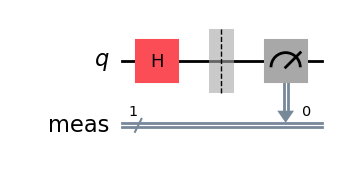


PART B : QUANTUM PENNY FLIP GAME
Coin starts at HEADS |0>.  Q plays H, C plays X or I, Q plays H.
Reveal: HEADS -> Quantum player wins, TAILS -> Classical wins.

--- Branch: C passes (does nothing) ---
  Final statevector : [1.+0.j 0.+0.j]
  Theoretical P(Quantum player wins) = 1.0000
  Simulated   (4096 games) counts  = {'0': 4096}  ->  1.0000

--- Branch: C flips the coin ---
  Final statevector : [1.+0.j 0.+0.j]
  Theoretical P(Quantum player wins) = 1.0000
  Simulated   (4096 games) counts  = {'0': 4096}  ->  1.0000

--- Overall Win Probabilities ---
  Quantum player  : 100.00 %
  Classical player: 0.00 %
  (A purely classical version of this game is 50 % / 50 %.)

--- Why it works ---
H puts the coin on the 'equator' of the Bloch sphere: |+>.
X leaves |+> completely unchanged, so the classical player's
move has no effect at all. The second H then returns the coin
to |0> = HEADS with certainty. Formally: H.X.H = Z and
H.I.H = I, and both Z|0> and I|0> measure as HEADS.

--- Verifi

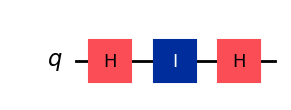

Branch 2: classical player flips


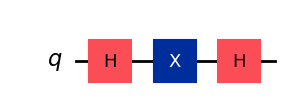

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

# ==============================================================
# WEEK 3 - REAL WORLD
# A quantum coin-flip game built from single-qubit gates.
#
#   The coin is one qubit:   |0> = HEADS ,  |1> = TAILS
#   "Flip the coin"      ->  X gate (deterministic flip)
#   "Shake the coin"     ->  H gate (puts it in superposition)
#
# PART A : a fair quantum coin toss.
# PART B : the Quantum Penny Flip game - a quantum player who is
#          allowed to use H beats a classical player 100% of the
#          time, even though the classical player moves in between.
# ==============================================================

SHOTS = 4096
sim = AerSimulator()
HEADS, TAILS = "0", "1"

# ==================================================================
# PART A - A FAIR QUANTUM COIN
# ==================================================================
print("=" * 62)
print("PART A : FAIR QUANTUM COIN TOSS")
print("=" * 62)

coin = QuantumCircuit(1)
coin.h(0)                       # shake the coin into superposition

state = Statevector.from_instruction(coin)
print("Coin state after H:")
print(state)
print(f"Theoretical P(HEADS) = {abs(state.data[0]) ** 2:.4f}, "
      f"P(TAILS) = {abs(state.data[1]) ** 2:.4f}")

coin_meas = coin.copy()
coin_meas.measure_all()
counts = sim.run(coin_meas, shots=SHOTS).result().get_counts()

print(f"\nExperiment ({SHOTS} tosses): {counts}")
print(f"  HEADS: {counts.get(HEADS, 0) / SHOTS:.4f}")
print(f"  TAILS: {counts.get(TAILS, 0) / SHOTS:.4f}")
print("=> A single H gate is a perfectly fair coin.")

display(coin_meas.draw(output="mpl", style="iqp"))

# ==================================================================
# PART B - THE QUANTUM PENNY FLIP GAME
# ==================================================================
# Rules:
#   The coin starts as HEADS (|0>).
#   Round 1: QUANTUM player moves   (allowed gate: H)
#   Round 2: CLASSICAL player moves (allowed: flip = X, or pass = I)
#   Round 3: QUANTUM player moves   (allowed gate: H)
#   The coin is then revealed. HEADS  -> quantum player wins.
#                              TAILS  -> classical player wins.
#
# The classical player cannot see the coin, so they guess: 50/50
# between flipping and passing.
print("\n" + "=" * 62)
print("PART B : QUANTUM PENNY FLIP GAME")
print("=" * 62)
print("Coin starts at HEADS |0>.  Q plays H, C plays X or I, Q plays H.")
print("Reveal: HEADS -> Quantum player wins, TAILS -> Classical wins.\n")

results = {}
for move, label in [("I", "C passes (does nothing)"), ("X", "C flips the coin")]:
    game = QuantumCircuit(1)
    game.h(0)                          # Q's first move
    if move == "X":
        game.x(0)                      # C's move
    else:
        game.id(0)                     # C's move (identity = pass)
    game.h(0)                          # Q's second move

    final = Statevector.from_instruction(game)
    p_heads = abs(final.data[0]) ** 2

    g = game.copy()
    g.measure_all()
    c = sim.run(g, shots=SHOTS).result().get_counts()
    measured_heads = c.get(HEADS, 0) / SHOTS

    results[move] = (p_heads, measured_heads, game)

    print(f"--- Branch: {label} ---")
    print(f"  Final statevector : {np.round(final.data, 4)}")
    print(f"  Theoretical P(Quantum player wins) = {p_heads:.4f}")
    print(f"  Simulated   ({SHOTS} games) counts  = {c}"
          f"  ->  {measured_heads:.4f}\n")

# ------------------ Overall win probability -----------------------
# The classical player picks each move with probability 1/2.
p_quantum_win = 0.5 * results["I"][0] + 0.5 * results["X"][0]
p_classical_win = 1 - p_quantum_win

print("--- Overall Win Probabilities ---")
print(f"  Quantum player  : {p_quantum_win * 100:.2f} %")
print(f"  Classical player: {p_classical_win * 100:.2f} %")
print("  (A purely classical version of this game is 50 % / 50 %.)")

print("\n--- Why it works ---")
print("H puts the coin on the 'equator' of the Bloch sphere: |+>.")
print("X leaves |+> completely unchanged, so the classical player's")
print("move has no effect at all. The second H then returns the coin")
print("to |0> = HEADS with certainty. Formally: H.X.H = Z and")
print("H.I.H = I, and both Z|0> and I|0> measure as HEADS.")

print("\n--- Verification ---")
if np.isclose(p_quantum_win, 1.0):
    print("STATUS: SUCCESS - the quantum strategy wins with probability 1,")
    print("beating the classical 50 % baseline. This is the quantum")
    print("advantage in game-theory form (Meyer's quantum penny flip).")
else:
    print("STATUS: FAILED")

print("\n--- Game Circuits ---")
print("Branch 1: classical player passes")
display(results["I"][2].draw(output="mpl", style="iqp"))
print("Branch 2: classical player flips")
display(results["X"][2].draw(output="mpl", style="iqp"))